In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
data = pd.read_csv('.//data//S&P 500 Stock Prices 2014-2017.csv')
data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')
# Display the first few rows of the dataset
data.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [46]:
# Find duplicate rows with the same 'symbol' and 'date'
duplicate_rows = data[data.duplicated(subset=['symbol', 'date'], keep=False)]
# Display the duplicate rows
duplicate_rows

,symbol,date,open,high,low,close,volume


In [65]:
unique_symbol, counts_unique_symbol = np.unique(data['symbol'], return_counts=True)
# Number of unique stocks
print(f'Number of unique stocks: {unique_symbol.size}')
# Number of records for each stock
stock_counts = pd.DataFrame({'symbol': unique_symbol, 'number_of_days': counts_unique_symbol})
# Display the count of records for each stock   
print('\nNumber of records for each stock:')
stock_counts

Number of unique stocks: 505

Number of records for each stock:


,symbol,number_of_days
0,A,1007
1,AAL,1007
2,AAP,1007
3,AAPL,1007
4,ABBV,1007
...,...,...
500,XYL,1007
501,YUM,1007
502,ZBH,1007
503,ZION,1007


In [66]:
# Basic stocks statistics by close value
stock_stats = data.groupby('symbol')['close'].agg(['mean', 'std', 'min', 'max'])
print('\nBasic stock statistics by close value:')
stock_stats


Basic stock statistics by close value:


,mean,std,min,max
symbol,,,,
A,49.097726,9.375208,33.3700,70.59
AAL,42.424900,6.063245,25.2700,55.76
AAP,143.187120,24.610670,79.3800,200.38
AAPL,116.839892,24.547273,71.3974,176.42
ABBV,63.338302,10.497342,46.4600,98.21
...,...,...,...,...
XYL,43.515228,9.704832,30.4600,69.34
YUM,76.402214,7.707074,59.7000,94.88
ZBH,110.586902,10.403532,90.8700,133.09


Text(0.5, 1.0, 'Total Volume by Date')

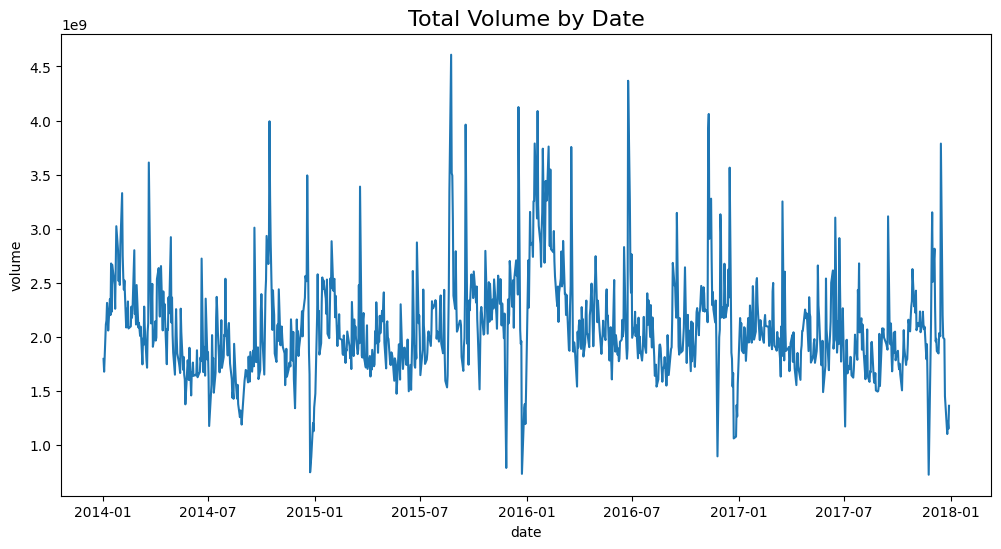

In [80]:
# Volume by date
volume_by_date = data.groupby('date')['volume'].sum().reset_index()
# Plot volume by date

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=volume_by_date, ax=ax, x='date', y='volume')
# plt.xticks(volume_by_date['date'][::50], [d.strftime('%d-%m-%y') for d in volume_by_date['date'][::50]], rotation=45)
    
ax.set_title('Total Volume by Date', fontsize=16)



1. Which date in the sample saw the largest overall trading volume? On that date, which two stocks were traded most?

In [ ]:
max_total_volume = volume_by_date['volume'].max()
ind = volume_by_date['volume'].idxmax()
max_total_volume_date = volume_by_date['date'][ind]
print(f'Max total volume: {max_total_volume} on date: {max_total_volume_date.dt.strftime("%d-%m-%Y")}')
print('\nTop 2 stocks with the highest volume on that date:')

data[data['date'] == max_total_volume_date].sort_values(by='volume', ascending=False).head(2)

AttributeError: 'Timestamp' object has no attribute 'dt'

2. On which day of the week does volume tend to be highest? Lowest?

Max volume by day of the week: Friday
Min volume by day of the week: Monday


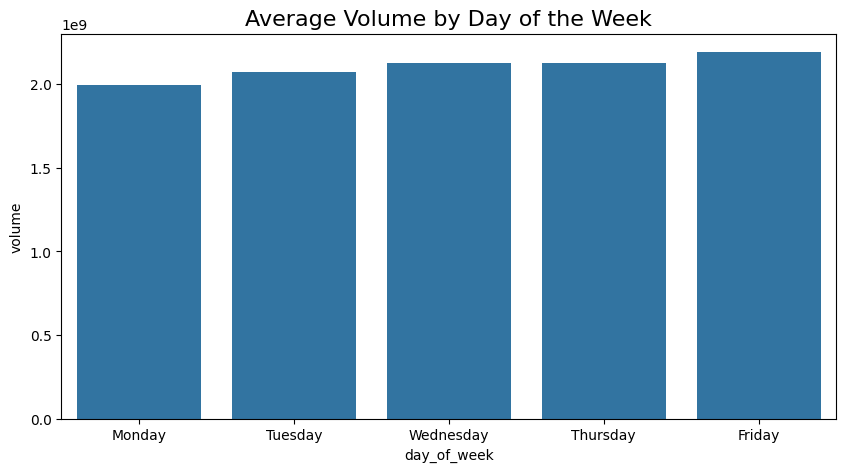

In [71]:
volume_by_date['day_of_week'] = volume_by_date['date'].dt.day_name()
volume_by_day_of_week = volume_by_date.groupby('day_of_week')['volume'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']).reset_index()
# Plot average volume by day of the week
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=volume_by_day_of_week, ax=ax, x='day_of_week', y='volume')
ax.set_title('Average Volume by Day of the Week', fontsize=16)

day_of_week_ind_max_volume = volume_by_day_of_week['volume'].argmax()
day_of_week_ind_min_volume = volume_by_day_of_week['volume'].argmin()
print(f'Max volume by day of the week: {volume_by_day_of_week["day_of_week"].iloc[day_of_week_ind_max_volume]}')
print(f'Min volume by day of the week: {volume_by_day_of_week["day_of_week"].iloc[day_of_week_ind_min_volume]}')


3. On which date did Amazon (AMZN) see the most volatility, measured by the difference between the high and low price?

Max volatility for AMZN: 85.99 on date: 2017-06-09 00:00:00


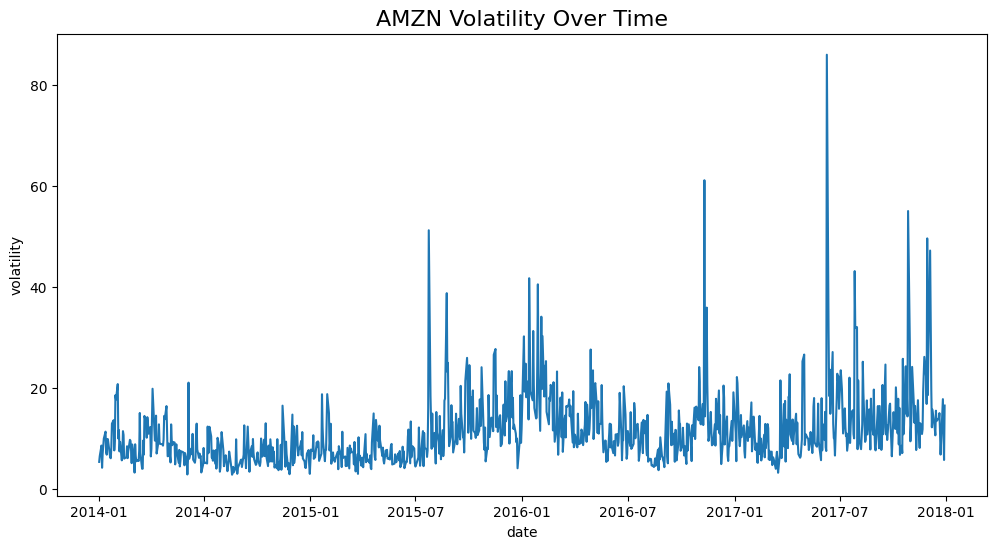

In [ ]:
amzn_data = data[data['symbol'] == 'AMZN'].copy()
amzn_data['volatility'] = amzn_data['high'] - amzn_data['low']
# Plot close price of AMZN over time
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=amzn_data, ax=ax, x='date', y='volatility')
ax.set_title('AMZN Volatility Over Time', fontsize=16)
# plt.xticks(amzn_data['date'][::50], [d.strftime('%d-%m-%y') for d in amzn_data['date'][::50]], rotation=45)

max_volatility_amzn = amzn_data['volatility'].max()
ind_max_volatility_amzn = amzn_data['volatility'].argmax()
max_volatility_amzn_date = amzn_data['date'].iloc[ind_max_volatility_amzn]

print(f'Max volatility for AMZN: {max_volatility_amzn:.2f} on date: {max_volatility_amzn_date.dt.strftime("%d-%m-%Y")}')
